In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [237]:
# Genero los 100n aleatorios
n = 100
aleatorios = np.random.standard_normal(n)

In [238]:
def proceso_ar(rho, y_prev, error):
    return rho * y_prev + error

def simular_proceso_ar(rho, n,errores):
    y = np.zeros(n)
    y[0] = errores[0]
    for i in range(1, n):
        error = errores[i]
        y[i] = proceso_ar(rho, y[i-1], error)
    return y

In [239]:
rho = 0.5
ar_0_5 = simular_proceso_ar(rho, n, aleatorios)
rho2 = 0.9
ar_0_9 = simular_proceso_ar(rho2, n, aleatorios)

In [240]:
df = pd.DataFrame({'white_noise':aleatorios,
                    'AR(1)0.5':ar_0_5,
                    'AR(1)0.9':ar_0_9})
df.head()

,white_noise,AR(1)0.5,AR(1)0.9
0,-0.217738,-0.217738,-0.217738
1,-0.724257,-0.833125,-0.920220
2,0.672718,0.256156,-0.155480
3,1.182296,1.310373,1.042363
4,-0.260886,0.394301,0.677241


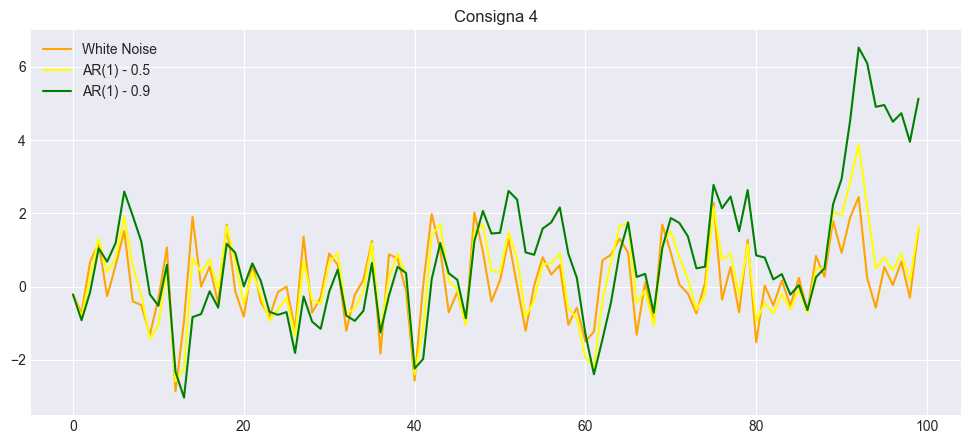

In [241]:
plt.plot(df["white_noise"], label="White Noise", color='orange')
plt.plot(df["AR(1)0.5"], label="AR(1) - 0.5", color='yellow')
plt.plot(df["AR(1)0.9"], label="AR(1) - 0.9", color='green')

plt.title("Consigna 4")
plt.legend()
plt.grid(True)
plt.show()

In [242]:
print(f"Media de white noise: {df['white_noise'].mean()} \nMedia de AR(1) 0.5: {df['AR(1)0.5'].mean()} \nMedia de AR(1) 0.9: {df['AR(1)0.9'].mean()}")

Media de white noise: 0.1248028380238909 
Media de AR(1) 0.5: 0.2331620466272869 
Media de AR(1) 0.9: 0.7864965284919689


5. Para generar diferentes procesos podemos volver a correr las celdas desde la generación del ruido blanco. No se notan variaciones significativas.

6. Los 3 procesos tienen media $\approx 0$.
El ruido blanco, basicamente por definición.
Y los dos AR(1), (recuerden de la clase que los podemos escribir como un MA infinito, y cada uno de los epsilon tiene esperanza cero) tendrán media
igual a cero. Noten que si hubiera una constante "c" en el AR(1), la media ya no sería 0. Pero sería constante. Si el proceso autorregresivo es débilmente estacionario, entonces la media existe.
En el gráfico podemos apreciar que estos procesos si bien pueden distanciarse de la media, en el tiempo retornan a la media.

# Regress

In [244]:
df["AR(1)0.5_lag"] = df["AR(1)0.5"].shift(1)
df["AR(1)0.9_lag"] = df["AR(1)0.9"].shift(1)
df_reg = df.dropna()

In [247]:
X_05 = df_reg[["AR(1)0.5_lag"]]
y_05 = df_reg["AR(1)0.5"]

modelo_05 = sm.OLS(y_05, X_05).fit()

print("AR(1) con rho = 0.5")
print(modelo_05.summary())
print("**" * 50)



AR(1) con rho = 0.5
                                 OLS Regression Results                                
Dep. Variable:               AR(1)0.5   R-squared (uncentered):                   0.204
Model:                            OLS   Adj. R-squared (uncentered):              0.196
Method:                 Least Squares   F-statistic:                              25.11
Date:                Wed, 26 Aug 2026   Prob (F-statistic):                    2.40e-06
Time:                        23:55:34   Log-Likelihood:                         -144.27
No. Observations:                  99   AIC:                                      290.5
Df Residuals:                      98   BIC:                                      293.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [248]:
X_09 = df_reg[["AR(1)0.9_lag"]]
y_09 = df_reg["AR(1)0.9"]

modelo_09 = sm.OLS(y_09, X_09).fit()

print("AR(1) con rho = 0.9")
print(modelo_09.summary())

AR(1) con rho = 0.9
                                 OLS Regression Results                                
Dep. Variable:               AR(1)0.9   R-squared (uncentered):                   0.729
Model:                            OLS   Adj. R-squared (uncentered):              0.726
Method:                 Least Squares   F-statistic:                              263.2
Date:                Wed, 26 Aug 2026   Prob (F-statistic):                    1.62e-29
Time:                        23:55:35   Log-Likelihood:                         -144.34
No. Observations:                  99   AIC:                                      290.7
Df Residuals:                      98   BIC:                                      293.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [249]:
print("Estimación de rho para AR(1) 0.5:", modelo_05.params.iloc[0])
print("Estimación de rho para AR(1) 0.9:", modelo_09.params.iloc[0])

Estimación de rho para AR(1) 0.5: 0.45615051592764166
Estimación de rho para AR(1) 0.9: 0.8835449114346638


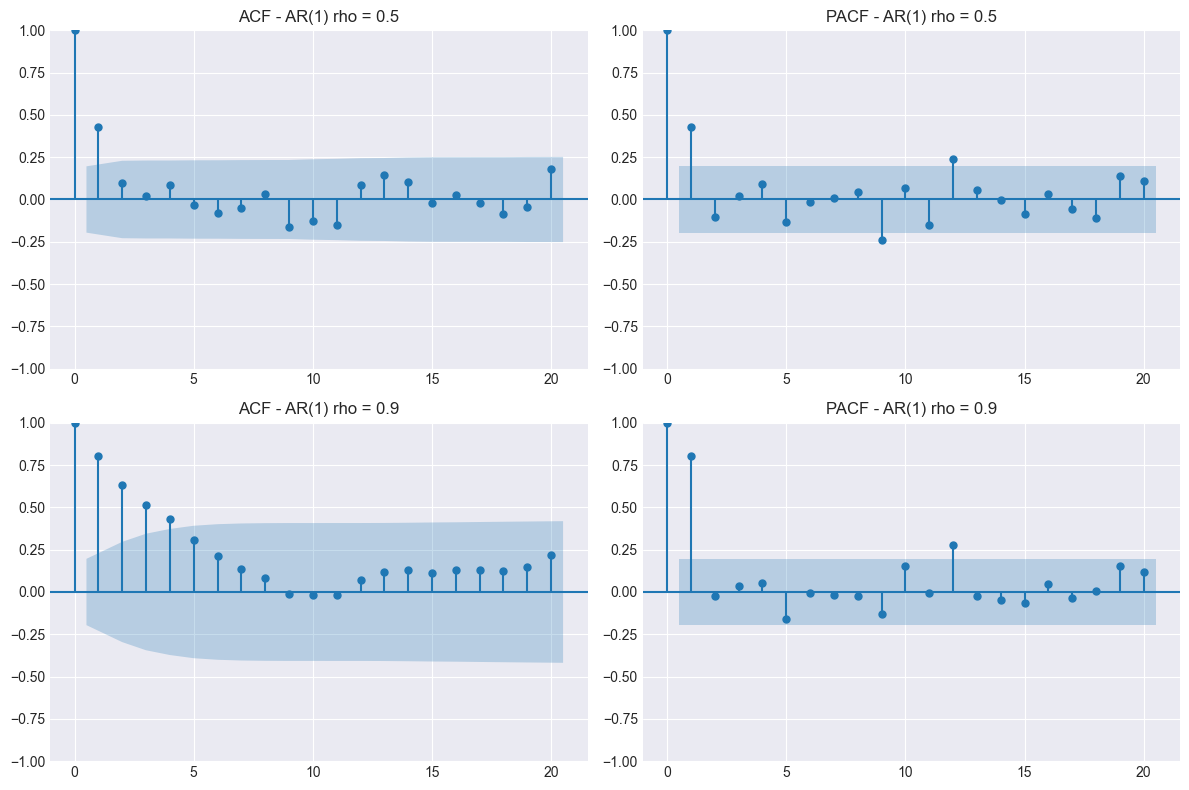

In [250]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(df["AR(1)0.5"], lags=20, ax=axes[0, 0])
axes[0, 0].set_title("ACF - AR(1) rho = 0.5")

plot_pacf(df["AR(1)0.5"], lags=20, ax=axes[0, 1])
axes[0, 1].set_title("PACF - AR(1) rho = 0.5")

plot_acf(df["AR(1)0.9"], lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF - AR(1) rho = 0.9")

plot_pacf(df["AR(1)0.9"], lags=20, ax=axes[1, 1])
axes[1, 1].set_title("PACF - AR(1) rho = 0.9")

plt.tight_layout()
plt.show()

In [256]:
ar1_05_params = np.array([1, -rho])
ar1_09_params = np.array([1, -rho2])
ma_params_base = np.array([1])
ar1_05_process = ArmaProcess(ar1_05_params, ma_params_base)
ar1_09_process = ArmaProcess(ar1_09_params, ma_params_base)


In [257]:
u_ar1_05 = ar1_05_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios
)

u_ar1_09 = ar1_09_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios
)

In [258]:
aleatorios_shock = aleatorios.copy()

aleatorios_shock[14] = 3

ar_0_5_shock = ar1_05_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios_shock
)

ar_0_9_shock = ar1_09_process.generate_sample(
    nsample=100,
    distrvs=lambda size: aleatorios_shock
)

df_shock = pd.DataFrame({
    "white_noise": aleatorios_shock,
    "AR(1) rho=0.5": ar_0_5_shock,
    "AR(1) rho=0.9": ar_0_9_shock
})

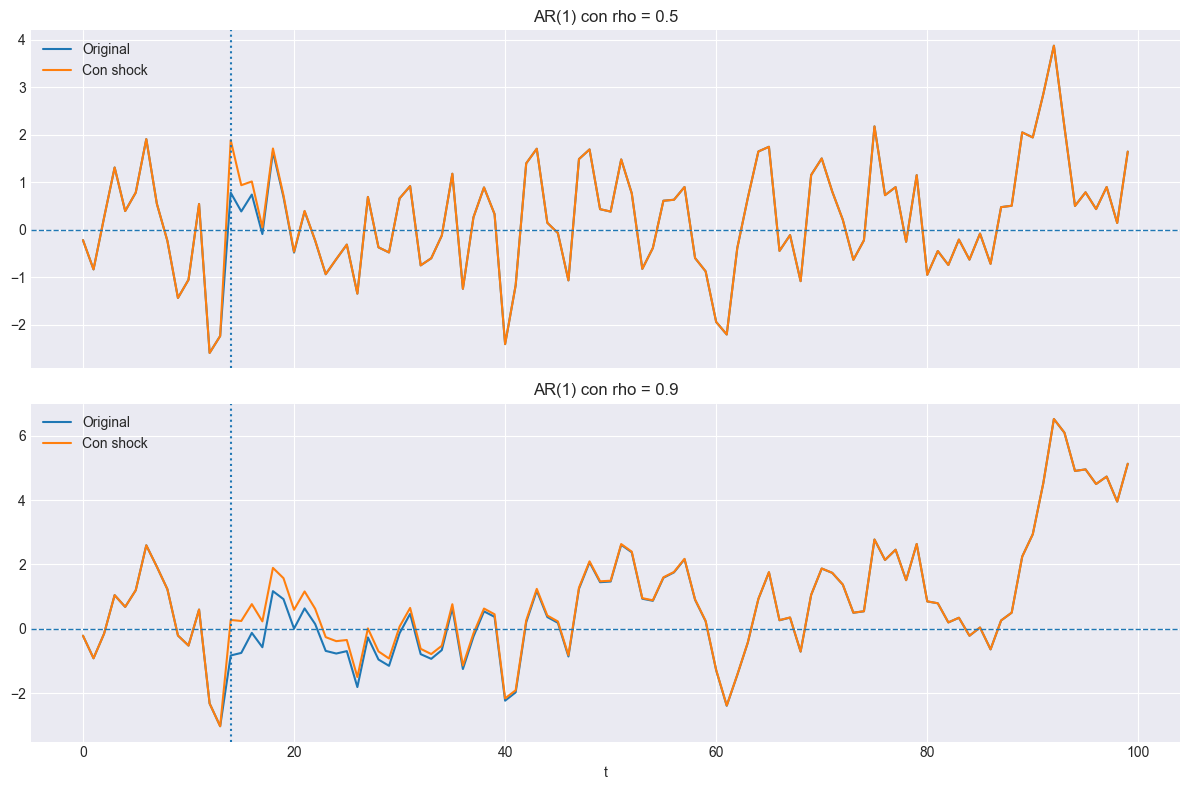

In [259]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(ar_0_5, label="Original")
axes[0].plot(ar_0_5_shock, label="Con shock")
axes[0].axvline(14, linestyle=":")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("AR(1) con rho = 0.5")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ar_0_9, label="Original")
axes[1].plot(ar_0_9_shock, label="Con shock")
axes[1].axvline(14, linestyle=":")
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("AR(1) con rho = 0.9")
axes[1].legend()
axes[1].grid(True)

plt.xlabel("t")
plt.tight_layout()
plt.show()

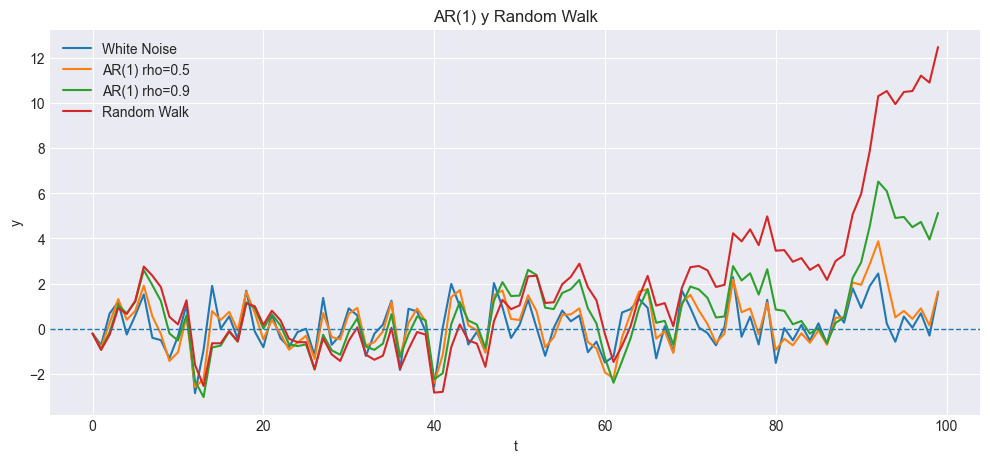

In [260]:
random_walk = simular_proceso_ar(1, n, aleatorios)

df_rw = pd.DataFrame({
    "white_noise": aleatorios,
    "AR(1) rho=0.5": ar_0_5,
    "AR(1) rho=0.9": ar_0_9,
    "Random Walk": random_walk
})

plt.figure(figsize=(12, 5))

plt.plot(
    df_rw["white_noise"],
    label="White Noise"
)

plt.plot(
    df_rw["AR(1) rho=0.5"],
    label="AR(1) rho=0.5"
)

plt.plot(
    df_rw["AR(1) rho=0.9"],
    label="AR(1) rho=0.9"
)

plt.plot(
    df_rw["Random Walk"],
    label="Random Walk"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("AR(1) y Random Walk")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

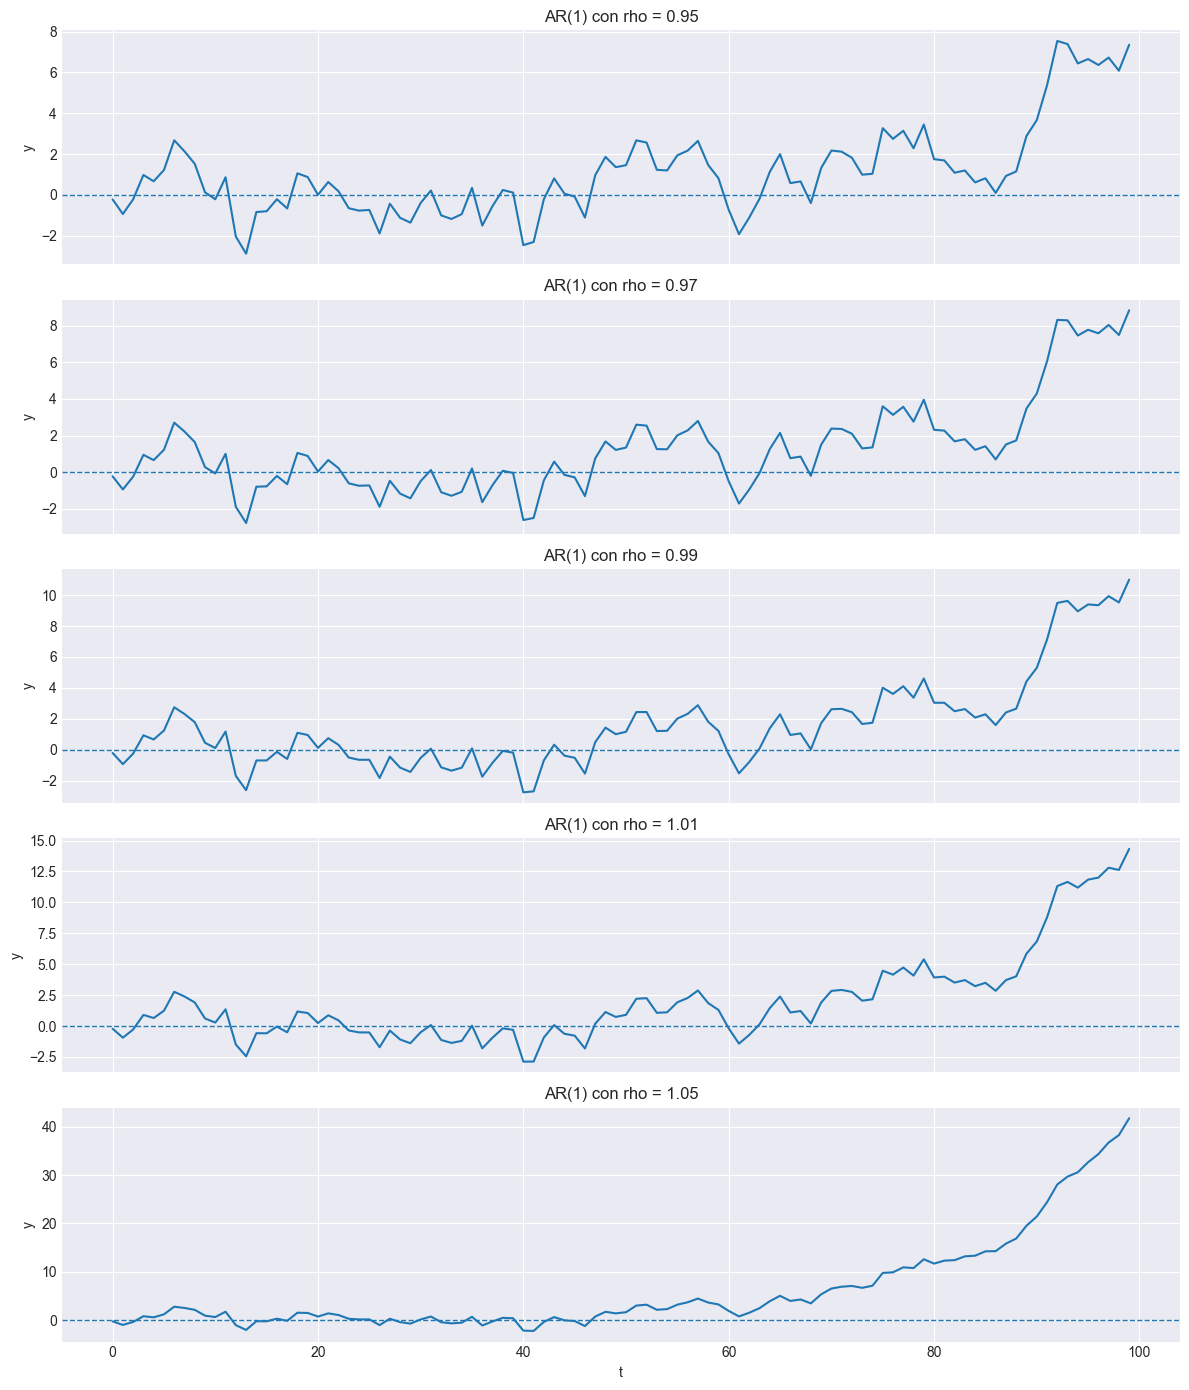

In [261]:
rhos = [0.95, 0.97, 0.99, 1.01, 1.05]

fig, axes = plt.subplots(
    len(rhos),
    1,
    figsize=(12, 14),
    sharex=True
)

for ax, rho in zip(axes, rhos):

    proceso = simular_proceso_ar(rho, n, aleatorios)

    ax.plot(proceso)
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"AR(1) con rho = {rho}")
    ax.set_ylabel("y")
    ax.grid(True)

axes[-1].set_xlabel("t")

plt.tight_layout()
plt.show()

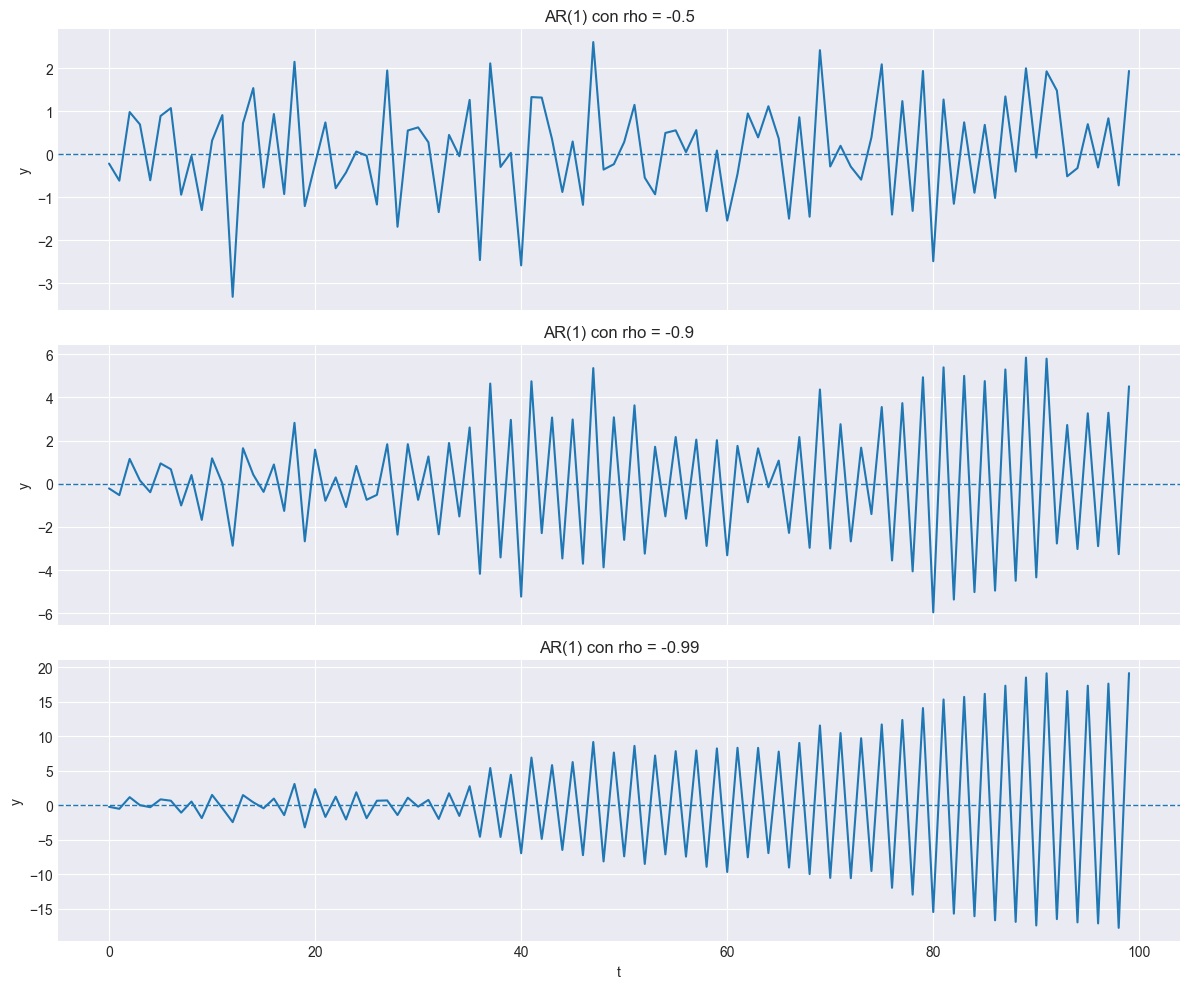

In [262]:
rhos_negativos = [-0.5, -0.9, -0.99]

fig, axes = plt.subplots(
    len(rhos_negativos),
    1,
    figsize=(12, 10),
    sharex=True
)

for ax, rho in zip(axes, rhos_negativos):

    proceso = simular_proceso_ar(rho, n, aleatorios)

    ax.plot(proceso)
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"AR(1) con rho = {rho}")
    ax.set_ylabel("y")
    ax.grid(True)

axes[-1].set_xlabel("t")

plt.tight_layout()
plt.show()